In [1]:
import numpy as np
import matplotlib.pylab as plt
import sys
sys.path.append("..")

from src.dg_utils import eval_orthonormal_legendre_1d
import scipy
import scipy.linalg

from src.research_utils_1d import(eval_dg_modal_local_nodes_1d, 
                                  apply_siac_modal_dg_local_nodes_1d, 
                                  trim_valid_siac_region_1d, 
                                  build_grid_from_local_nodes_1d)

In [2]:
def local_cell_center_nodes_1d(nloc):
    """
    Equispaced cell-center locations on [-1,1] for nloc equal subcells.
    """
    if not isinstance(nloc, int):
        raise TypeError("nloc must be an integer.")
    if nloc <= 0:
        raise ValueError("nloc must be positive.")

    j = np.arange(nloc)
    return -1.0 + (2.0 * j + 1.0) / nloc


def build_cell_center_grid_1d(xlim, N):
    x_left, x_right = xlim
    dx = (x_right - x_left) / N
    edges = np.linspace(x_left, x_right, N + 1)
    cell_centers = 0.5 * (edges[:-1] + edges[1:])

    grid = {
        "grid_edges": edges,
        "dx": dx,
        "cell_centers": cell_centers,
        "x_left": x_left,
        "x_right": x_right,
        "N": N,   # number of cells = number of cell centers
    }
    return grid


def build_dg_mesh_1d(grid, p, points_per_element=None, K=None):
    order = p + 1
    N = grid["N"]
    dx = grid["dx"]
    x_left = grid["x_left"]
    
    # Choose one primary discretization parameter
    if points_per_element is not None and K is not None:
        raise ValueError(
            "Specify only one of points_per_element or K, not both."
        )
        
    if points_per_element is None and K is None:
        ppe = 2 * order
        K = int(np.ceil(N / ppe))
        
    elif points_per_element is not None:
        ppe = int(points_per_element)
        if ppe <= 0:
            raise ValueError("points_per_element must be positive.")
        K = int(np.ceil(N / ppe))
    else:  # K is not None
        K = int(K)
        if K <= 0:
            raise ValueError("K must be positive.")
        ppe = int(np.ceil(N / K))

    # Total number of fine cells after padding
    N_pad = K * ppe
    n_pad_right = N_pad - N

    # Padded fine grid
    padded_edges = x_left + dx * np.arange(N_pad + 1)
    padded_centers = x_left + dx * (np.arange(N_pad) + 0.5)

    # Original/padded mask
    is_original = np.zeros(N_pad, dtype=bool)
    is_original[:N] = True

    # DG element edges
    h = ppe * dx
    element_edges = x_left + h * np.arange(K + 1)
    
    elem_left = element_edges[:-1]
    elem_right = element_edges[1:]
    
    # Element-to-fine-cell map
    elem_point_idx = [np.arange(e * ppe, (e + 1) * ppe) for e in range(K)]

    mesh = {
        # core info
        "p": p,
        "order": order,
        "K": K,
        "h": h,
        "dx": dx,
        "x_left": x_left,

        # fine-grid sizes
        "N": N,                  # backward-compatible
        "N_original": N,
        "N_pad": N_pad,          # backward-compatible
        "N_padded": N_pad,
        "n_pad_right": n_pad_right,

        # ppe naming
        "ppe": ppe,              # short alias
        "points_per_element": ppe,

        # padded fine grid
        "x_edges": padded_edges,     # backward-compatible
        "x_centers": padded_centers, # backward-compatible
        "fine_edges_padded": padded_edges,
        "fine_centers_padded": padded_centers,
        "is_original": is_original,

        # DG mesh
        "edges": element_edges,
        "element_edges": element_edges,
        "elem_left": elem_left,
        "elem_right": elem_right,
        "elem_point_idx": elem_point_idx,
    }

    return mesh

def dg_l2_approx(arr, mesh):
    """
    Compute elementwise discrete L2 projection of sampled 1D data
    onto DG polynomials of degree p using midpoint-rule quadrature.

    Parameters
    ----------
    arr : ndarray, shape (N_original,)
        Sampled data at original fine-grid cell centers.
    mesh : dict
        Mesh dictionary containing DG mesh and padded fine-grid structure.

    Returns
    -------
    dg : dict
        Dictionary with DG coefficients and metadata.
    """
    arr = np.asarray(arr, dtype=float)

    p = mesh["p"]
    order = p + 1
    ppe = mesh["points_per_element"]
    K = mesh["K"]
    dx = mesh["dx"]

    elem_point_idx = mesh["elem_point_idx"]
    is_original = mesh["is_original"]
    N_padded = mesh["N_padded"]

    # Build padded data array
    arr_padded = np.zeros(N_padded, dtype=float)
    arr_padded[is_original] = arr

    # Reference cell-center nodes in [-1,1]
    nodes = local_cell_center_nodes_1d(nloc=ppe)

    # Evaluate orthonormal Legendre basis at local nodes
    # shape: (order, ppe)
    Phi_loc = eval_orthonormal_legendre_1d(x=nodes, p=p)

    # Midpoint-rule mass matrix (same on every element)
    M = dx * (Phi_loc @ Phi_loc.T)

    # LU factorization once, reused for every element
    lu, piv = scipy.linalg.lu_factor(M)

    coeffs = np.zeros((K, order), dtype=float)

    for e in range(K):
        idx = elem_point_idx[e]       # global point indices for element e
        vals = arr_padded[idx]        # local sampled values, shape (ppe,)

        b = dx * (Phi_loc @ vals)         # shape (order,)
        c = scipy.linalg.lu_solve((lu, piv), b)

        coeffs[e, :] = c

    dg = {
        "coeffs": coeffs,
        "p": p,
        "order": order,
        "mesh": mesh,
        "basis": "orthonormal_legendre",
    }

    return dg
        
    
    

In [3]:
def exact_poly1d_scaled(x, degree=4, xlim=(-1,1)):
    x = np.asarray(x)
    
    # map to [-1,1]
    xhat = 2*(x - xlim[0]) / (xlim[1] - xlim[0]) - 1
    
    poly = 0.1 * np.ones_like(xhat)
    if degree >= 1:
        poly += 0.3*xhat
    if degree >= 2:
        poly += 0.5*xhat**2
    if degree >= 3:
        poly += -0.7*xhat**3
    if degree >= 4:
        poly += 0.25*xhat**4
    if degree >= 5:
        poly += -0.5*xhat**5
    
    return poly

# setup
xlim = (-5, 5)
N = 400     # number of cell centers (samples)
# grid
grid_coarse = build_cell_center_grid_1d(xlim=xlim, N=N)
# exact function on coarse grid
poly_deg = 5
exact_coarse = exact_poly1d_scaled(x=grid_coarse["cell_centers"], degree=poly_deg, xlim=xlim)


# DG stuff
p = int(np.ceil((poly_deg - 1) / 2))
order = p + 1

# Postprocessor stuff
moments = 2*p
BSorder = p + 1

# points per element for L2 projection
ppe = int(p + np.floor(order / 2))
# ppe = 2 * p

# build DG mesh
mesh = build_dg_mesh_1d(grid=grid_coarse, p=p, points_per_element=ppe)

# Build modal DG representation
dg = dg_l2_approx(arr=exact_coarse, mesh=mesh)


# fine evaluation grid
n_eval = 50 * ppe
eval_nodes = local_cell_center_nodes_1d(n_eval)
grid_fine = build_grid_from_local_nodes_1d(mesh, eval_nodes=eval_nodes)

# exact solution on fine grid
U_exact = exact_poly1d_scaled(x=grid_fine, degree=poly_deg, xlim=xlim)

# evaluate DG on fine grid
U_dg = eval_dg_modal_local_nodes_1d(dg, eval_nodes=eval_nodes)

# apply SIAC and evaluate at fine grid
U_siac = apply_siac_modal_dg_local_nodes_1d(dg, moments=moments, BSorder=BSorder, eval_nodes=eval_nodes)

# Trim to interior region
_, trim = trim_valid_siac_region_1d(arr=U_exact, n_eval=n_eval, moments=moments, BSorder=BSorder, return_trim=True)

# Extra full DG element on the right if the mesh was padded
extra_right = n_eval if mesh["n_pad_right"] > 0 else 0

left_trim = trim
right_trim = trim + extra_right

if left_trim == 0 and right_trim == 0:
    sl = slice(None)
elif right_trim == 0:
    sl = slice(left_trim, None)
else:
    sl = slice(left_trim, -right_trim)
    
exact_trim = U_exact[sl]
dg_trim = U_dg[sl]
siac_trim = U_siac[sl]
    

# -----------------------------
# 8. Errors (interior only comparison)
# -----------------------------
err_dg = dg_trim - exact_trim
err_siac = siac_trim - exact_trim

print("DG max err   :", np.max(np.abs(err_dg)))
print("DG rel err   :", np.linalg.norm(err_dg) / np.linalg.norm(exact_trim))

print("SIAC max err :", np.max(np.abs(err_siac)))
print("SIAC rel err :", np.linalg.norm(err_siac) / np.linalg.norm(exact_trim))



DG max err   : 1.3633599020845821e-06
DG rel err   : 4.885596650508991e-07
SIAC max err : 1.279626848926796e-09
SIAC rel err : 1.722463668283169e-09


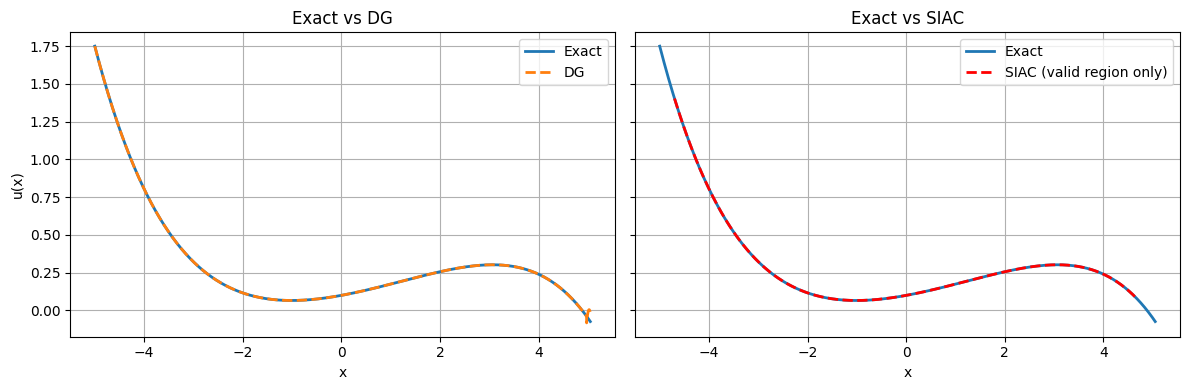

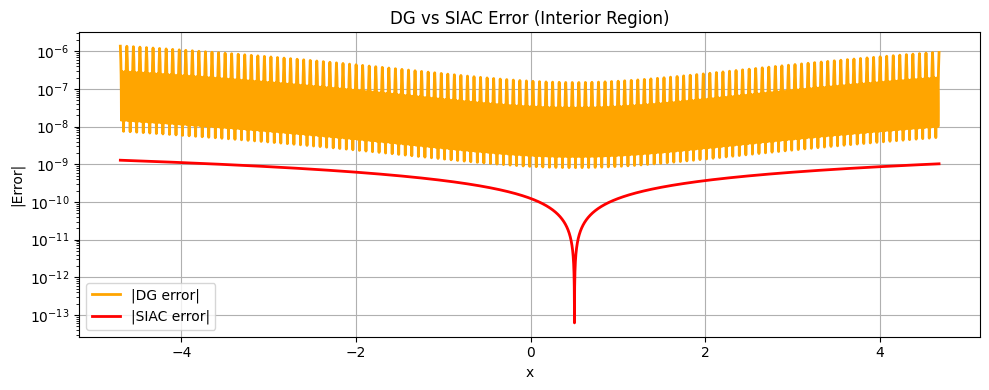

In [4]:
siac_plot = np.full_like(grid_fine, np.nan, dtype=float)
siac_plot[sl] = siac_trim

err_siac_plot = np.full_like(grid_fine, np.nan, dtype=float)
err_siac_plot[sl] = err_siac

# Optional: NaN-padded exact and DG errors too, if you want same-length arrays
err_dg_plot = np.full_like(grid_fine, np.nan, dtype=float)
err_dg_plot[sl] = err_dg

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

# Left: full Exact vs full DG
axes[0].plot(grid_fine, U_exact, label="Exact", linewidth=2)
axes[0].plot(grid_fine, U_dg, "--", label="DG", linewidth=2)
axes[0].set_title("Exact vs DG")
axes[0].set_xlabel("x")
axes[0].set_ylabel("u(x)")
axes[0].grid(True)
axes[0].legend()

# Right: full Exact + SIAC only on valid interior
axes[1].plot(grid_fine, U_exact, label="Exact", linewidth=2)
axes[1].plot(grid_fine, siac_plot, "--", color="r", label="SIAC (valid region only)", linewidth=2)
axes[1].set_title("Exact vs SIAC")
axes[1].set_xlabel("x")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))

# DG error (padded or trimmed)
ax.semilogy(grid_fine, np.abs(err_dg_plot), 
            label="|DG error|", linewidth=2, color="orange")

# SIAC error (NaN outside valid region)
ax.semilogy(grid_fine, np.abs(err_siac_plot), 
            label="|SIAC error|", linewidth=2, color="red")

ax.set_title("DG vs SIAC Error (Interior Region)")
ax.set_xlabel("x")
ax.set_ylabel("|Error|")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

**NOTE** Observe the behavior of the DG solution near the right boundary. Unless the points per element ($ppe$) and the number of elements $K$ satisfy
$$
    ppe * K = N
$$
where $N$ is the number of original samples, the grid does not divide evenly into elements. In this case, the domain is extended by zero-padding on the right to complete the final element.

As a result, the DG approximation in the last element is influenced by these artificial zeros, which introduces visible errors near the right edge.

This behavior is expected in the current 1D setup. The implementation is designed with a future 2D application in mind, where the data (e.g., images) are assumed to be compactly supported strictly within the domain. In that setting, zero-padding outside the support is consistent with the true function, and this boundary artifact does not occur.

In [5]:
def sine_cos_curve(x, xlim=(-1,1), scale=False):
    x = np.asarray(x, dtype=float)
    if scale:
        xhat = 2 * (x - xlim[0]) / (xlim[1] - xlim[0]) - 1.0
    else:
        xhat = x
    
    return np.sin(np.pi*xhat) #+ np.cos(2*np.pi*xhat)

# setup
xlim = (-5, 5)
# DG polynomial degree
p = 2
order = p + 1

# DG mesh resolution
K = 64
N = K * order       # number of samples at cell centers

# SIAC parameters
moments = 2*p
BSorder = p + 1



# grid
grid_coarse = build_cell_center_grid_1d(xlim=xlim, N=N)
# exact function on coarse grid
scale_flag = False
exact_coarse = sine_cos_curve(x=grid_coarse["cell_centers"], xlim=xlim, scale=scale_flag)


# SIAC parameters
moments = 2*p
BSorder = p + 1

# points per element for L2 projection
ppe = int(order + np.floor(order / 2))
# ppe = 2 * p

# build DG mesh
# defined via number of elements K
mesh = build_dg_mesh_1d(grid=grid_coarse, p=p, K=K)
# defined via ppe
#mesh = build_dg_mesh_1d(grid=grid_coarse, p=p, points_per_element=ppe)


# Build modal DG representation
dg = dg_l2_approx(arr=exact_coarse, mesh=mesh)


# fine evaluation grid
n_eval = 2**6 * ppe
eval_nodes = local_cell_center_nodes_1d(n_eval)
grid_fine = build_grid_from_local_nodes_1d(mesh, eval_nodes=eval_nodes)

# exact solution on fine grid
U_exact = sine_cos_curve(x=grid_fine, xlim=xlim, scale=scale_flag)

# evaluate DG on fine grid
U_dg = eval_dg_modal_local_nodes_1d(dg, eval_nodes=eval_nodes)

# apply SIAC and evaluate at fine grid
U_siac = apply_siac_modal_dg_local_nodes_1d(dg, moments=moments, BSorder=BSorder, eval_nodes=eval_nodes)

# Trim to interior region
_, trim = trim_valid_siac_region_1d(arr=U_exact, n_eval=n_eval, moments=moments, BSorder=BSorder, return_trim=True)

# Extra full DG element on the right if the mesh was padded
extra_right = n_eval if mesh["n_pad_right"] > 0 else 0

left_trim = trim
right_trim = trim + extra_right

if left_trim == 0 and right_trim == 0:
    sl = slice(None)
elif right_trim == 0:
    sl = slice(left_trim, None)
else:
    sl = slice(left_trim, -right_trim)
    
exact_trim = U_exact[sl]
dg_trim = U_dg[sl]
siac_trim = U_siac[sl]
    

# -----------------------------
# 8. Errors (interior only comparison)
# -----------------------------
err_dg = dg_trim - exact_trim
err_siac = siac_trim - exact_trim

print("DG max err   :", np.max(np.abs(err_dg)))
print("DG rel err   :", np.linalg.norm(err_dg) / np.linalg.norm(exact_trim))

print("SIAC max err :", np.max(np.abs(err_siac)))
print("SIAC rel err :", np.linalg.norm(err_siac) / np.linalg.norm(exact_trim))



DG max err   : 0.0013410898687892248
DG rel err   : 0.0004437807110215327
SIAC max err : 2.1334933053118732e-05
SIAC rel err : 2.1285156561824232e-05


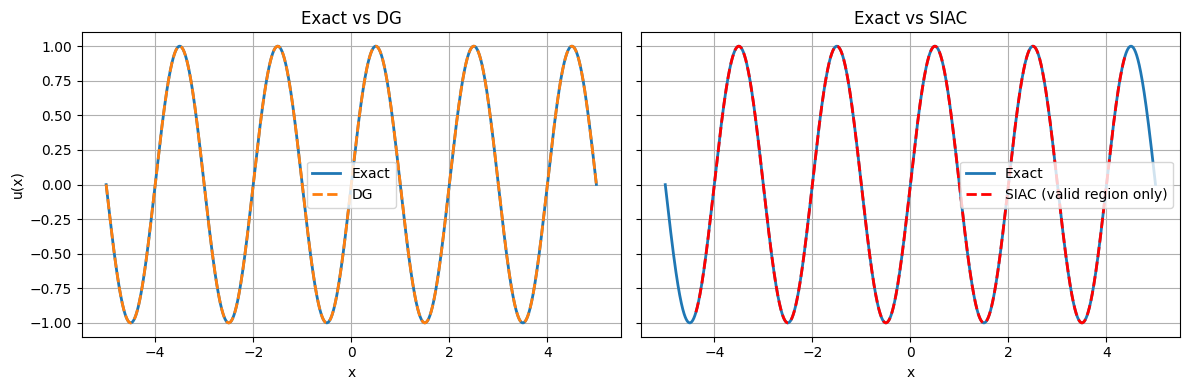

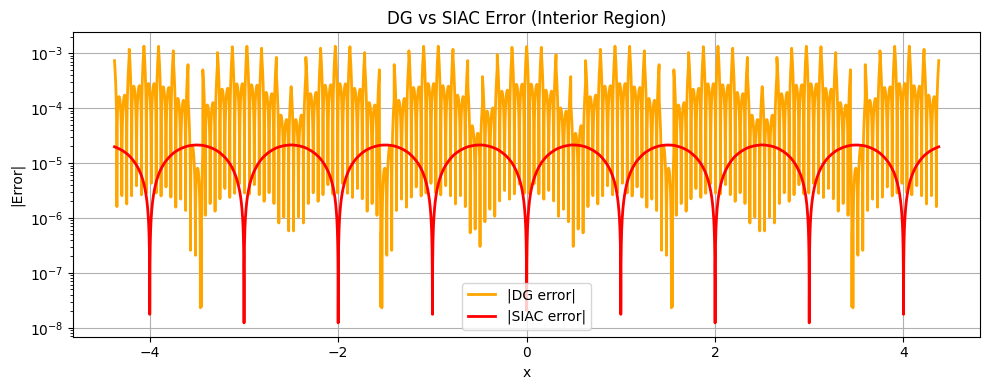

In [6]:
siac_plot = np.full_like(grid_fine, np.nan, dtype=float)
siac_plot[sl] = siac_trim

err_siac_plot = np.full_like(grid_fine, np.nan, dtype=float)
err_siac_plot[sl] = err_siac

# Optional: NaN-padded exact and DG errors too, if you want same-length arrays
err_dg_plot = np.full_like(grid_fine, np.nan, dtype=float)
err_dg_plot[sl] = err_dg

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

# Left: full Exact vs full DG
axes[0].plot(grid_fine, U_exact, label="Exact", linewidth=2)
axes[0].plot(grid_fine, U_dg, "--", label="DG", linewidth=2)
axes[0].set_title("Exact vs DG")
axes[0].set_xlabel("x")
axes[0].set_ylabel("u(x)")
axes[0].grid(True)
axes[0].legend()

# Right: full Exact + SIAC only on valid interior
axes[1].plot(grid_fine, U_exact, label="Exact", linewidth=2)
axes[1].plot(grid_fine, siac_plot, "--", color="r", label="SIAC (valid region only)", linewidth=2)
axes[1].set_title("Exact vs SIAC")
axes[1].set_xlabel("x")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))

# DG error (padded or trimmed)
ax.semilogy(grid_fine, np.abs(err_dg_plot), 
            label="|DG error|", linewidth=2, color="orange")

# SIAC error (NaN outside valid region)
ax.semilogy(grid_fine, np.abs(err_siac_plot), 
            label="|SIAC error|", linewidth=2, color="red")

ax.set_title("DG vs SIAC Error (Interior Region)")
ax.set_xlabel("x")
ax.set_ylabel("|Error|")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

### Convergence study

In [7]:
def convergence_study_dg_siac_1d_fixed_samples(
    exact_fun,
    K_values,
    p,
    xlim=(-1, 1),
    N_fine=1024,
    fine_factor=50,
    moments=None,
    BSorder=None,
    quad_order=None,
    min_ppe=None,
    exact_fun_kwargs=None,
):
    """
    Convergence-style study for 1D DG + SIAC using one fixed fine sampled grid.

    For each K in K_values:
      - use the same fixed fine sampled data,
      - define ppe = N_fine // K,
      - build DG mesh with K elements,
      - project sampled data to degree-p DG,
      - evaluate DG and SIAC on a fine grid,
      - compare errors on the valid trimmed region.

    Parameters
    ----------
    exact_fun : callable
        Exact function with signature exact_fun(x=..., xlim=..., **kwargs).
    K_values : array_like of int
        Requested DG element counts, e.g. [8, 16, 32, 64].
    p : int
        DG polynomial degree.
    xlim : tuple
        Physical domain.
    N_fine : int
        Number of fixed fine-grid cell-center samples.
    fine_factor : int
        Number of evaluation points per coarse sample point inside each DG element:
            n_eval = fine_factor * ppe
    moments : int or None
        SIAC reproduction parameter. Defaults to 2*p.
    BSorder : int or None
        SIAC B-spline order. Defaults to p+1.
    quad_order : int or None
        Optional quadrature order for SIAC integrals.
    min_ppe : int or None
        Minimum acceptable points per element.
        If None, uses p + 1.
    exact_fun_kwargs : dict or None
        Extra kwargs passed to exact_fun.

    Returns
    -------
    results : dict
        Arrays of valid runs only.
    """
    if moments is None:
        moments = 2 * p
    if BSorder is None:
        BSorder = p + 1
    if exact_fun_kwargs is None:
        exact_fun_kwargs = {}
    if min_ppe is None:
        min_ppe = p + 1

    K_values = np.asarray(K_values, dtype=int)

    # Optional: check doubling pattern if desired
    assert np.all(K_values[1:] == 2 * K_values[:-1]), \
        "K_values must double each step, e.g. [8,16,32,64]"

    # -------------------------------------------------
    # 1. Build one fixed fine sampled grid and data
    # -------------------------------------------------
    grid_fine_samples = build_cell_center_grid_1d(xlim=xlim, N=N_fine)
    exact_samples = exact_fun(
        x=grid_fine_samples["cell_centers"],
        xlim=xlim,
        **exact_fun_kwargs
    )

    K_list = []
    ppe_list = []
    h_list = []

    dg_max_list = []
    dg_rel_l2_list = []

    siac_max_list = []
    siac_rel_l2_list = []

    for_loop_lenght = len(K_values)
    for iter, K in enumerate(K_values):
        print(f"Iteration {iter+1} of {for_loop_lenght}, K = {K} ")
        
        # -------------------------------------------------
        # 2. Check if this K is compatible with fixed sample grid
        # -------------------------------------------------
        if N_fine % K != 0:
            print(f"Skipping K={K}: N_fine={N_fine} is not divisible by K.")
            continue

        ppe = N_fine // K

        if ppe < min_ppe:
            print(f"Stopping at K={K}: ppe={ppe} < min_ppe={min_ppe}.")
            break

        # -------------------------------------------------
        # 3. Build DG mesh from the same fixed sampled grid
        # -------------------------------------------------
        mesh = build_dg_mesh_1d(
            grid=grid_fine_samples,
            p=p,
            K=K,   # now explicitly fixed
        )

        h = mesh["h"]

        # -------------------------------------------------
        # 4. Build modal DG representation from fixed samples
        # -------------------------------------------------
        dg = dg_l2_approx(arr=exact_samples, mesh=mesh)

        # -------------------------------------------------
        # 5. Fine evaluation grid for this DG mesh
        # -------------------------------------------------
        n_eval = int(fine_factor * ppe)
        eval_nodes = local_cell_center_nodes_1d(n_eval)
        grid_eval = build_grid_from_local_nodes_1d(mesh, eval_nodes=eval_nodes)

        # -------------------------------------------------
        # 6. Exact, DG, SIAC on same evaluation grid
        # -------------------------------------------------
        U_exact = exact_fun(x=grid_eval, xlim=xlim, **exact_fun_kwargs)
        U_dg = eval_dg_modal_local_nodes_1d(dg, eval_nodes=eval_nodes)
        U_siac = apply_siac_modal_dg_local_nodes_1d(
            dg,
            moments=moments,
            BSorder=BSorder,
            eval_nodes=eval_nodes,
            quad_order=quad_order,
        )

        # -------------------------------------------------
        # 7. Trim valid SIAC region and remove extra padded right element
        # -------------------------------------------------
        _, trim = trim_valid_siac_region_1d(
            arr=U_exact,
            n_eval=n_eval,
            moments=moments,
            BSorder=BSorder,
            return_trim=True,
        )

        extra_right = n_eval if mesh["n_pad_right"] > 0 else 0

        left_trim = trim
        right_trim = trim + extra_right

        if left_trim == 0 and right_trim == 0:
            sl = slice(None)
        elif right_trim == 0:
            sl = slice(left_trim, None)
        else:
            sl = slice(left_trim, -right_trim)

        exact_trim = U_exact[sl]
        dg_trim = U_dg[sl]
        siac_trim = U_siac[sl]

        # -------------------------------------------------
        # 8. Errors
        # -------------------------------------------------
        err_dg = dg_trim - exact_trim
        err_siac = siac_trim - exact_trim

        dg_max = np.max(np.abs(err_dg))
        dg_rel_l2 = np.linalg.norm(err_dg) / np.linalg.norm(exact_trim)

        siac_max = np.max(np.abs(err_siac))
        siac_rel_l2 = np.linalg.norm(err_siac) / np.linalg.norm(exact_trim)

        # -------------------------------------------------
        # 9. Store
        # -------------------------------------------------
        K_list.append(K)
        ppe_list.append(ppe)
        h_list.append(h)

        dg_max_list.append(dg_max)
        dg_rel_l2_list.append(dg_rel_l2)

        siac_max_list.append(siac_max)
        siac_rel_l2_list.append(siac_rel_l2)

    return {
        "N_fine": int(N_fine),
        "K": np.asarray(K_list, dtype=int),
        "ppe": np.asarray(ppe_list, dtype=int),
        "h": np.asarray(h_list, dtype=float),
        "dg_max": np.asarray(dg_max_list, dtype=float),
        "dg_rel_l2": np.asarray(dg_rel_l2_list, dtype=float),
        "siac_max": np.asarray(siac_max_list, dtype=float),
        "siac_rel_l2": np.asarray(siac_rel_l2_list, dtype=float),
    }

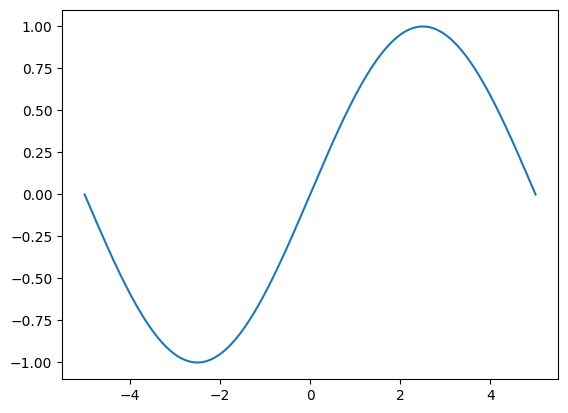

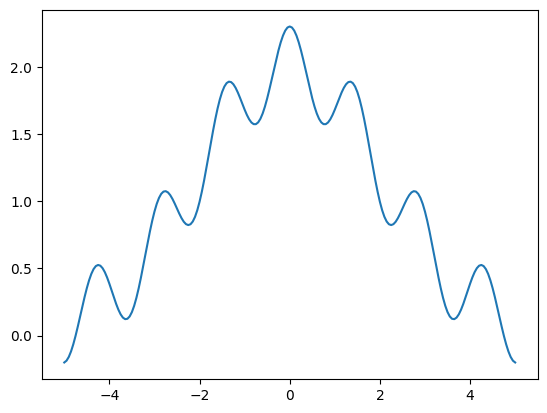

In [8]:
def exact_bumped_trig1d(x, xlim=(-1, 1), alpha=3.0):
    x = np.asarray(x, dtype=float)

    xhat = 2 * (x - xlim[0]) / (xlim[1] - xlim[0]) - 1.0
    return (
        2*np.exp(-alpha * xhat**2)
        + (0.3 * np.cos(7 * np.pi * xhat))
    )

def exact_trig1d(x, xlim=(-1, 1)):
    x = np.asarray(x, dtype=float)
    
    xhat = 2 * (x - xlim[0]) / (xlim[1] - xlim[0]) - 1.0
    return np.sin(np.pi * xhat)


xlim = (-5, 5)
x_test = np.linspace(xlim[0], xlim[1], 201)

plt.plot(x_test, exact_trig1d(x_test, xlim))
plt.show()

plt.plot(x_test, exact_bumped_trig1d(x_test, xlim))
plt.show()

In [9]:

# DG stuff
p = 2
order = p + 1

# Postprocessor
moments = 2 * p
BSorder = p + 1

# grid information
xlim = (-1, 1)

# convergence information
halfker = int(np.ceil(moments + BSorder)/2)

start_K = max(12, 4 * halfker)
K_values = start_K * 2**np.arange(10)
fine_factor = 20

Kmax = np.max(K_values)
N_fine = int(Kmax * fine_factor * order)


quad_order = 2*p+4

results = convergence_study_dg_siac_1d_fixed_samples(
    exact_fun=exact_trig1d, 
    K_values=K_values, 
    p=p,
    xlim=xlim,
    N_fine=N_fine,
    fine_factor=fine_factor, 
    moments=moments, 
    BSorder=BSorder, 
    quad_order=quad_order, 
    min_ppe=order
)


Iteration 1 of 10, K = 12 
Iteration 2 of 10, K = 24 
Iteration 3 of 10, K = 48 
Iteration 4 of 10, K = 96 
Iteration 5 of 10, K = 192 
Iteration 6 of 10, K = 384 
Iteration 7 of 10, K = 768 
Iteration 8 of 10, K = 1536 
Iteration 9 of 10, K = 3072 
Iteration 10 of 10, K = 6144 


DG rates   : [3.94511501 2.93563741 2.88416303 2.93639472 2.968544   2.98455939
 2.9923755  2.99621559 2.99811826]
SIAC rates : [5.94430849 5.98601911 5.9965292  5.99956495 6.00706325 6.05649841
 1.00656092 0.06111938 0.03163524]


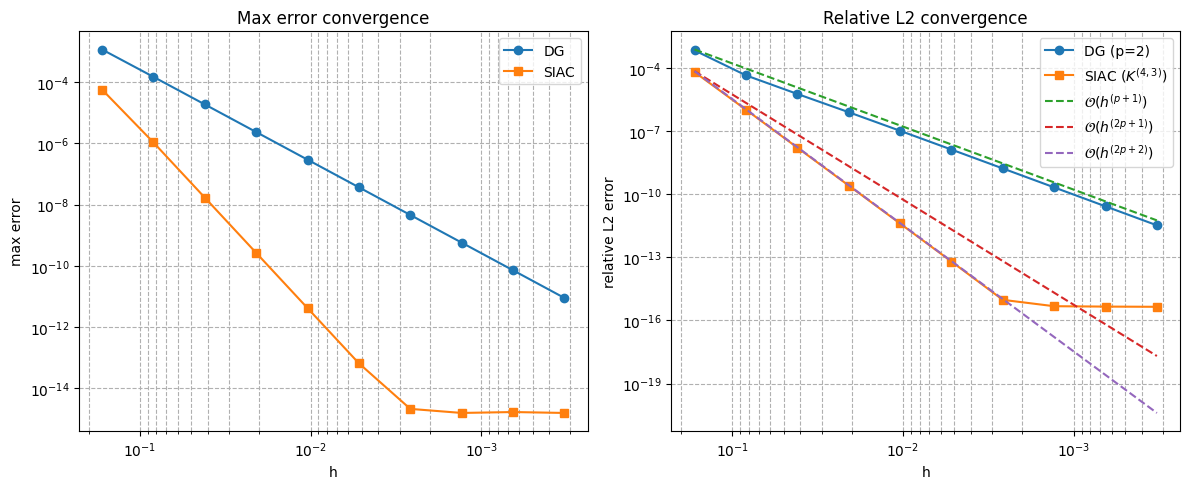

DG errors       p=2
Initial rel. L2 error for DG with   K=12:       0.0007041981509369097
Initial max error for DG with       K=12:       0.0011613471294128126

Final rel. L2 error for DG with     K=6144:       3.364246206813982e-12
Final max error for DG with         K=6144:       8.877083963743093e-12


SIAC errors     r=5, n=3
Initial rel. L2 error for DG with   K=12:       6.550001642344138e-05
Initial max error for DG with       K=12:       5.692795419620644e-05

Final rel. L2 error for DG with     K=6144:       4.4797100880872e-16
Final max error for DG with         K=6144:       1.5543122344752192e-15




In [ ]:
hs = results["h"]
Ks = results["K"]

dg_max = results["dg_max"]
siac_max = results["siac_max"]

dg_rel_l2 = results["dg_rel_l2"]
siac_rel_l2 = results["siac_rel_l2"]

# Extract
hs = results["h"]

dg_max = results["dg_max"]
siac_max = results["siac_max"]

dg_rel_l2 = results["dg_rel_l2"]
siac_rel_l2 = results["siac_rel_l2"]

# -------------------------
# Helper: compute slopes
# -------------------------
def compute_rates(h, err):
    rates = np.log(err[:-1] / err[1:]) / np.log(h[:-1] / h[1:])
    return rates

dg_rates = compute_rates(hs, dg_rel_l2)
siac_rates = compute_rates(hs, siac_rel_l2)

print("DG rates   :", dg_rates)
print("SIAC rates :", siac_rates)


# -------------------------
# Plot
# -------------------------
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# --- Max error ---
axs[0].loglog(hs, dg_max, "o-", label="DG")
axs[0].loglog(hs, siac_max, "s-", label="SIAC")

axs[0].set_xlabel("h")
axs[0].set_ylabel("max error")
axs[0].set_title("Max error convergence")
axs[0].grid(True, which="both", ls="--")
axs[0].legend()

# --- Relative L2 ---
axs[1].loglog(hs, dg_rel_l2, "o-", label=f"DG (p={p})")
axs[1].loglog(hs, siac_rel_l2, "s-", label = f"SIAC ($K^{{({moments}, {BSorder})}}$)")

axs[1].set_xlabel("h")
axs[1].set_ylabel("relative L2 error")
axs[1].set_title("Relative L2 convergence")
axs[1].grid(True, which="both", ls="--")
axs[1].legend()

def add_reference_line(ax, h, err, order, label):
    c = 1.1*err[0] / (h[0]**order)
    ax.loglog(h, c * h**order, "--", label=label)

# expected DG order ~ p+1, SIAC ~ 2p+1 (roughly)

add_reference_line(axs[1], hs, dg_rel_l2, p+1, "$\mathcal{O}(h^{(p+1)})$")
add_reference_line(axs[1], hs, siac_rel_l2, 2*p+1, "$\mathcal{O}(h^{(2p+1)})$")
add_reference_line(axs[1], hs, siac_rel_l2, 2*p+2, "$\mathcal{O}(h^{(2p+2)})$")

axs[1].legend()

axs[0].invert_xaxis()
axs[1].invert_xaxis()
plt.tight_layout()
plt.show()

Kmin, Kmax = np.min(K_values), np.max(K_values)
print(f"DG errors       p={p}")
print(f"Initial rel. L2 error with   K={Kmin}:       {dg_rel_l2[0]}")
print(f"Initial max error with       K={Kmin}:       {dg_max[0]}\n")
print(f"Final rel. L2 error with     K={Kmax}:       {dg_rel_l2[-1]}")
print(f"Final max error with         K={Kmax}:       {dg_max[-1]}\n\n")

print(f"SIAC errors     r={moments+1}, n={BSorder}")
print(f"Initial rel. L2 error with   K={Kmin}:       {siac_rel_l2[0]}")
print(f"Initial max error with       K={Kmin}:       {siac_max[0]}\n")
print(f"Final rel. L2 error with     K={Kmax}:       {siac_rel_l2[-1]}")
print(f"Final max error with         K={Kmax}:       {siac_max[-1]}\n\n")
